In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

import astropy.units as u
from astropy.coordinates import cartesian_to_spherical, SkyCoord, Galactocentric

from collections import defaultdict

from scipy.ndimage import median_filter
from scipy.signal import savgol_filter



%load_ext line_profiler

import plotparams 
plotparams.default()

source = '/cosma5/data/durham/dc-pick2/simulations'

In [2]:
# import funcs

%run ./utils.ipynb
%run ./utilsMassProfile.ipynb
%run ./utilsStream.ipynb

In [3]:
with open(source + '/Mass/100000/global.30') as f:
    header_line = f.readline()
    data_line   = f.readline()


header_tokens = header_line.split()
data_tokens   = data_line.split()
print(len(header_tokens), len(data_tokens))

# print them aligned, walking both lists together up to the point they diverge
for i, h in enumerate(header_tokens):
    print(i, h, '->', data_tokens[i])

64 65
0 TIME[NB} -> 0.00000000000000000E+00
1 TIME[Myr] -> 0.00000000000000000E+00
2 TCR[Myr] -> 0.27168876087972036E+01
3 DE -> 0.00000000000000000E+00
4 BE(3) -> -0.24999999994412003E+00
5 RSCALE[PC] -> 0.59923953946153228E+01
6 RTIDE[PC] -> 0.59923953946153240E+02
7 RDENS[PC] -> 0.14124798873939107E+00
8 RC[PC] -> 0.18343855497109898E+01
9 RHOD[M*] -> 0.24817706498271768E+04
10 RHOM[M*] -> 0.26056437094797035E+05
11 MC[M*] -> 0.81356096871988584E+04
12 CMAX -> 0.10479109029605240E+02
13 <Cn> -> 0.17000517406438223E+03
14 Ir/R -> 0.18205580636698988E-01
15 RCM -> 0.31554696114047349E-16
16 VCM -> 0.70787911824715769E-16
17 AZ -> -0.30841807634711380E-02
18 EB/E -> -0.00000000000000000E+00
19 EM/E -> -0.00000000000000000E+00
20 VRMS -> 0.59905364378297685E+01
21 N -> 56454
22 NS -> 56454
23 NPAIRS -> 0
24 NUPKS -> 0
25 NPKS -> 0
26 NMERGE -> 0
27 MULT -> 0
28 <NB> -> 82
29 NC -> 4416
30 NESC -> 0
31 NSTEPI -> 0
32 NSTEPB -> 0
33 NSTEPR -> 0
34 NSTEPU -> 0
35 NSTEPT -> 0
36 NSTEPQ -> 0

In [8]:
hyades_path = source + '/Hyades'
times = [625]

step = get_steps_at_times(hyades_path, times)
step_df = step[625]

stream_df = filter_stream(step_df)

x,y,z,m = stream_df[['X','Y','Z','M']].T.to_numpy()


In [9]:
history = []
com = shrinking_sphere(x, y, z, m, history=history, r=25, rate=0.8)

history = np.asarray(history)
history

array([[-1006.2765  ,   520.0188  ,   -22.45205 ],
       [-1006.3829  ,   520.06116 ,   -22.85999 ],
       [-1006.4251  ,   519.9609  ,   -22.81709 ],
       [-1006.3921  ,   519.9639  ,   -22.810535],
       [-1006.4145  ,   520.17883 ,   -22.761639],
       [-1006.4275  ,   520.14355 ,   -22.553457],
       [-1006.4804  ,   520.0545  ,   -22.47845 ],
       [-1006.338   ,   520.0548  ,   -22.460201],
       [-1006.2771  ,   520.034   ,   -22.512672]], dtype=float32)

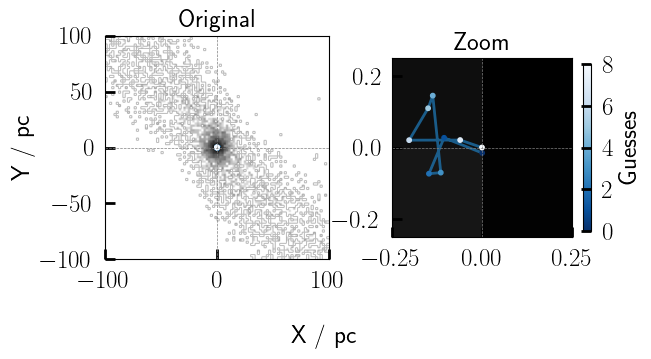

In [13]:
offset = 100
zoom_offset = 0.25

fig, ax = plt.subplots(1,2, figsize=(6,4))

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[0].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)
hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[1].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)


histx = history.T[0]
histy = history.T[1]

ax[0].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75)
ax[1].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75, linewidth=2)

ax[0].scatter(histx - com[0], histy - com[1], label='guesses', marker='o',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)
cb = ax[1].scatter(histx - com[0], histy - com[1], label='COM guesses', marker='o',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)

cbar = plt.colorbar(cb, ax=ax[1], shrink=0.4, label='Guesses')
cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))


ax[0].set_xlim(-offset, offset)
ax[0].set_ylim(- offset, offset)
ax[0].set_aspect('equal')
ax[0].set_title('Original')


ax[1].set_xlim(-zoom_offset, zoom_offset)
ax[1].set_ylim(- zoom_offset, zoom_offset)
ax[1].set_aspect('equal')
ax[1].set_title('Zoom')

ax[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[0].axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axvline(0, color='gray', linewidth=0.5, linestyle='--')

fig.supxlabel('X / pc', fontsize=18)
ax[0].set_ylabel('Y / pc')
plt.tight_layout(pad=-0.5)

#fig.suptitle('Shrinking Shpere Centre of Mass', y=0.85)
plt.savefig('Images/ShrinkShereCOM.png', bbox_inches='tight')

plt.show()